<a href="https://colab.research.google.com/github/SentineNet-AI-SpringBoard/SentinelNet-AI/blob/AI-sentineNet-Rohan/Milstone_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**milestone**-**2**

Week 3: Feature Engineering and Selection

In [ ]:
# Separating dataset columns into categorical and numerical features for preprocessing in SentiNet AI
import pandas as pd
import numpy as np

# Load the data if not already loaded (assuming df is available from previous steps)
try:
    df
except NameError:
    file_path = '/content/drive/MyDrive/Wednesday-workingHours.pcap_ISCX.csv'
    df = pd.read_csv(file_path)

categorical_features = df.select_dtypes(include=['object']).columns
numerical_features = df.select_dtypes(include=['int64','float64']).columns

print("Categorical:", categorical_features)
print("Numerical:", numerical_features)

Categorical: Index([' Label'], dtype='object')
Numerical: Index([' Destination Port', ' Flow Duration', ' Total Fwd Packets',
       ' Total Backward Packets', 'Total Length of Fwd Packets',
       ' Total Length of Bwd Packets', ' Fwd Packet Length Max',
       ' Fwd Packet Length Min', ' Fwd Packet Length Mean',
       ' Fwd Packet Length Std', 'Bwd Packet Length Max',
       ' Bwd Packet Length Min', ' Bwd Packet Length Mean',
       ' Bwd Packet Length Std', 'Flow Bytes/s', ' Flow Packets/s',
       ' Flow IAT Mean', ' Flow IAT Std', ' Flow IAT Max', ' Flow IAT Min',
       'Fwd IAT Total', ' Fwd IAT Mean', ' Fwd IAT Std', ' Fwd IAT Max',
       ' Fwd IAT Min', 'Bwd IAT Total', ' Bwd IAT Mean', ' Bwd IAT Std',
       ' Bwd IAT Max', ' Bwd IAT Min', 'Fwd PSH Flags', ' Bwd PSH Flags',
       ' Fwd URG Flags', ' Bwd URG Flags', ' Fwd Header Length',
       ' Bwd Header Length', 'Fwd Packets/s', ' Bwd Packets/s',
       ' Min Packet Length', ' Max Packet Length', ' Packet Length Mean',

In [ ]:
###LabelEncoder converts text categories like 'Positive' to numbers like 0 for machine learning models. This gives each unique label a unique integer,
 ##which the model can easily use for training.

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder() #Encodes according to the alphabetical order
df[' Label'] = le.fit_transform(df[' Label'])
print(df[' Label'].unique())

[0 4 3 2 1 5]


In [ ]:
# Saving the preprocessed and encoded dataset to a new CSV file 'Wednesday_Encoded.csv'
df.to_csv("Wednesday_Encoded.csv", index=False)

Correlation with target:
 Label                   1.000000
Idle Max                0.609972
Fwd IAT Max             0.609484
Flow IAT Max            0.608738
Fwd IAT Std             0.605762
                          ...   
Fwd Avg Packets/Bulk         NaN
Fwd Avg Bulk Rate            NaN
Bwd Avg Bytes/Bulk           NaN
Bwd Avg Packets/Bulk         NaN
Bwd Avg Bulk Rate            NaN
Name: Label, Length: 79, dtype: float64


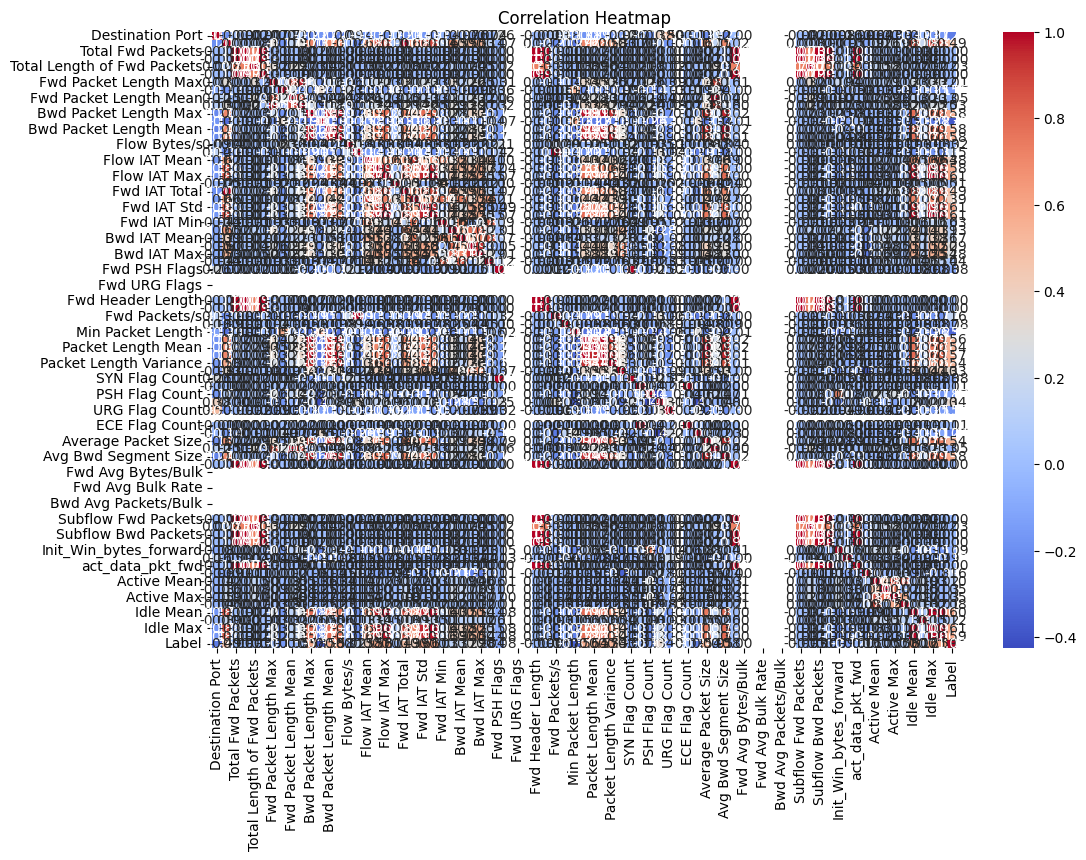

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Compute correlation with target
corr_matrix = df.corr()
target_corr = corr_matrix['Label'].sort_values(ascending=False)  # replace 'target_column'

print("Correlation with target:\n", target_corr)

# Heatmap of all numerical features
plt.figure(figsize=(12,8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

In [ ]:
# 1. Select only numeric columns for the correlation calculation
numeric_df = df.select_dtypes(include=['int64', 'float64'])

# 2. Clean column names to remove any leading/trailing spaces
df.columns = df.columns.str.strip()

# 3. Check if the 'Label' column exists before calculating correlation
if 'Label' in numeric_df.columns:

    # 4. Compute the correlation matrix
    corr_matrix = numeric_df.corr()

    # 5. Get the absolute correlation of all features with the 'Label' column
    target_corr = corr_matrix.abs()['Label']

    # 6. Identify important features (correlation > 0.3)
    important_features = target_corr[target_corr > 0.3].index.tolist()

    # 7. Identify non-important features (correlation <= 0.3)
    non_important_features = target_corr[target_corr <= 0.3].index.tolist()

    # --- Print the lists of features ---
    print("Important Features:", important_features)
    print("Non-Important Features:", non_important_features)

    # 8. Create a new DataFrame with only the important features
    df_filtered = df[important_features]

    # --- Print the final shape of the filtered DataFrame ---
    print("Shape after dropping non-important features:", df_filtered.shape)

else:
    print("Error: The 'Label' column was not found in the numeric columns.")

Important Features: ['Flow Duration', 'Bwd Packet Length Max', 'Bwd Packet Length Min', 'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Min Packet Length', 'Max Packet Length', 'Packet Length Mean', 'Packet Length Std', 'Packet Length Variance', 'FIN Flag Count', 'ACK Flag Count', 'Average Packet Size', 'Avg Bwd Segment Size', 'Idle Mean', 'Idle Max', 'Idle Min', 'Label']
Non-Important Features: ['Destination Port', 'Total Fwd Packets', 'Total Backward Packets', 'Total Length of Fwd Packets', 'Total Length of Bwd Packets', 'Fwd Packet Length Max', 'Fwd Packet Length Min', 'Fwd Packet Length Mean', 'Fwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s', 'Flow IAT Min', 'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Fwd Header Length', 'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s', 'SYN Flag Count', 

In [ ]:
# --- Separate the data into features (X) and the target (y) ---

# X contains all the important feature columns (the inputs for the model).
# We use .drop() to remove the 'Label' column because it's what we want to predict.
X = df_filtered.drop(columns=['Label'])

# y contains only the target column (the output the model will learn to predict).
y = df_filtered['Label']

# --- Print the shapes to verify the separation ---
print("Features (X) shape:", X.shape)
print("Target (y) shape:", y.shape)

Features (X) shape: (692703, 24)
Target (y) shape: (692703,)


In [ ]:
from sklearn.impute import SimpleImputer

# Fill missing values with median (robust for numeric data)
imputer = SimpleImputer(strategy='median')

X_imputed = imputer.fit_transform(X)
X_imputed = pd.DataFrame(X_imputed, columns=X.columns)

In [ ]:
from sklearn.preprocessing import StandardScaler
import numpy as np

# Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed)

# Verify no NaNs remain
print("Number of NaNs after scaling:", np.isnan(X_scaled).sum())

Number of NaNs after scaling: 0


In [ ]:
from sklearn.decomposition import PCA

# Fit PCA on scaled data
pca = PCA() ## all components for full analysis
X_pca = pca.fit_transform(X_scaled)

In [ ]:
print("Shape before PCA:", X_scaled.shape)
print("Shape after PCA:", X_pca.shape)

Shape before PCA: (692703, 24)
Shape after PCA: (692703, 24)


In [ ]:
explained_variance = pd.DataFrame({
    'PC': [f'PC{i+1}' for i in range(len(pca.explained_variance_))],
    'Explained_Variance': pca.explained_variance_ratio_
}).sort_values(by='Explained_Variance', ascending=False)



In [ ]:
# Display top 10 PCA components
top_10_pca = explained_variance.head(10)
print("Top 10 PCA Components based on explained variance:")
print(top_10_pca)

Top 10 PCA Components based on explained variance:
     PC  Explained_Variance
0   PC1            0.678993
1   PC2            0.100233
2   PC3            0.073841
3   PC4            0.043907
4   PC5            0.028685
5   PC6            0.022891
6   PC7            0.016112
7   PC8            0.011182
8   PC9            0.008515
9  PC10            0.005450


In [ ]:
from sklearn.model_selection import train_test_split
# Split dataset into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [ ]:
# Extract feature importance
importances = rf.feature_importances_

# Create a DataFrame to visualize importance
feature_importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# Display top 10 most important features
top_10_features = feature_importance_df.head(10)
print("Top 10 Features contributing to attacks:")
print(top_10_features)

Top 10 Features contributing to attacks:
                   Feature  Importance
4    Bwd Packet Length Std    0.106314
3   Bwd Packet Length Mean    0.101689
13       Max Packet Length    0.079471
15       Packet Length Std    0.073889
20    Avg Bwd Segment Size    0.071288
14      Packet Length Mean    0.069066
1    Bwd Packet Length Max    0.056376
7             Flow IAT Max    0.052816
19     Average Packet Size    0.051889
16  Packet Length Variance    0.047630


In [ ]:
from sklearn.ensemble import RandomForestClassifier
# Initialize Random Forest with 50 trees as suggested
rf = RandomForestClassifier(n_estimators=50, random_state=42, n_jobs=-1)

# Train the model
rf.fit(X_train, y_train)

RandomForestClassifier(n_estimators=50, n_jobs=-1, random_state=42)

4. Supervised Model Training

In [ ]:

#RANDOM FOREST MODEL TRAINING
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Train Random Forest using only the top 10 features
rf_top10 = RandomForestClassifier(n_estimators=50, random_state=42)
rf_top10.fit(X_train_top10, y_train)

# Make predictions
y_pred_rf_top10 = rf_top10.predict(X_test_top10)

# Evaluate performance
print("Random Forest:")
print("Accuracy:", accuracy_score(y_test, y_pred_rf_top10))
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf_top10))


Random Forest:
Accuracy: 0.9920486359344899

Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.99      0.99    125111
           1       0.97      0.97      0.97      3086
           2       0.99      0.99      0.99     51855
           3       0.97      0.99      0.98      1568
           4       1.00      0.99      1.00      1616
           5       1.00      1.00      1.00         3

    accuracy                           0.99    183239
   macro avg       0.99      0.99      0.99    183239
weighted avg       0.99      0.99      0.99    183239

In [ ]:
#SVM MODEL TRAINING
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report

# Train SVM model on top 10 features
svm_top10 = SVC(kernel='rbf', random_state=42)
svm_top10.fit(X_train_top10, y_train)

# Predictions
y_pred_svm_top10 = svm_top10.predict(X_test_top10)

# Evaluation
print("SVM:")
print("Accuracy:", accuracy_score(y_test, y_pred_svm_top10))
print("\nClassification Report:\n", classification_report(y_test, y_pred_svm_top10))

SVM:
Accuracy: 0.9580220367934774

Classification Report:
               precision    recall  f1-score   support

           0       0.95      1.00      0.97    125111
           1       0.95      0.68      0.79      3086
           2       1.00      0.90      0.94     51855
           3       0.70      0.84      0.76      1568
           4       0.62      0.54      0.58      1616
           5       1.00      1.00      1.00         3

    accuracy                           0.96    183239
   macro avg       0.87      0.83      0.84    183239
weighted avg       0.96      0.96      0.96    183239


In [ ]:
#LOGISTIC REGRESSION MODEL TRAINING
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# Train Logistic Regression on top 10 features
logreg_top10 = LogisticRegression(max_iter=1000, random_state=42)
logreg_top10.fit(X_train_top10, y_train)

# Predictions
y_pred_logreg_top10 = logreg_top10.predict(X_test_top10)

# Evaluation
print("Logistic Regression:")
print("Accuracy:", accuracy_score(y_test, y_pred_logreg_top10))
print("\nClassification Report:\n", classification_report(y_test, y_pred_logreg_top10))

Logistic Regression:
Accuracy: 0.9433035543743417

Classification Report:
               precision    recall  f1-score   support

           0       0.94      1.00      0.96    125111
           1       0.86      0.44      0.58      3086
           2       0.98      0.89      0.93     51855
           3       0.46      0.06      0.10      1568
           4       0.50      0.24      0.32      1616
           5       0.75      1.00      0.86         3

    accuracy                           0.94    183239
   macro avg       0.75      0.60      0.63    183239
weighted avg       0.94      0.94      0.94    183239

Final Model Evaluation Summary (Simplified)

Random Forest performed best with 99.20% accuracy, showing strong and consistent results across all types of network traffic.

SVM achieved 95.80% accuracy, effectively capturing complex patterns but slightly struggled with less frequent attack types.

Logistic Regression got 94.33% accuracy, working well as a simple and fast model but less effective for complex intrusion patterns.

All three models confirmed that the data preprocessing and feature selection were done correctly.

Random Forest is the most reliable model for network intrusion detection in SentinelNet-AI due to its superior accuracy and robustness.